In [22]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "seaborn"])

import sklearn
print(sklearn.__version__)

1.7.2


### 2-2. Scikit-learn의 공통 API 패턴

```python
from sklearn.XXX import 모델이름

model = 모델이름()
model.fit(X_train, y_train)   # 학습
model.predict(X_test)         # 예측
model.score(X_test, y_test)   # 평가
```

In [23]:
# 데이터 준비 — 붓꽃(iris) 데이터셋 로드
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data              # 특성 (150, 4)
y = iris.target            # 레이블 (150,)
feature_names = iris.feature_names

print(f"데이터 크기: {X.shape}")
print(f"특성 이름: {feature_names}")
print(f"클래스: {list(iris.target_names)}")

데이터 크기: (150, 4)
특성 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
클래스: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [24]:
# 2-3. 훈련 / 테스트 데이터 분리

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20%를 테스트용으로
    random_state=42,    # 재현 가능한 결과를 위한 시드값
    stratify=y          # 클래스 비율 유지 (분류 문제에서 권장)
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [25]:
# 3-2. K-최근접 이웃 (KNN)

from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(model.score(X_test, y_test))

1.0


In [26]:
# 3-3. 결정 트리 (Decision Tree)

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.9666666666666667


In [27]:
# 3-4. 랜덤 포레스트 (Random Forest)

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)
print(f"정확도: {model.score(X_test, y_test):.4f}")

importance = pd.Series(model.feature_importances_, index=feature_names)
print(importance.sort_values(ascending=False))

정확도: 0.9333
petal width (cm)     0.438141
petal length (cm)    0.431641
sepal length (cm)    0.115972
sepal width (cm)     0.014246
dtype: float64


In [28]:
# 3-5. 실습 — 붓꽃(iris) 품종 분류

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"정확도: {model.score(X_test, y_test):.4f}")  # 예: 1.0000

정확도: 0.9000


In [29]:
# 4-2. 선형 회귀 (Linear Regression)

from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array([[2], [4], [6], [8], [10]])
y = np.array([50, 65, 75, 85, 95])

model = LinearRegression()
model.fit(X, y)

print(model.predict([[7]]))            # 예: [80.0]
print(f"기울기: {model.coef_[0]:.2f}")
print(f"절편: {model.intercept_:.2f}")
print(f"R² 점수: {model.score(X, y):.4f}")

[79.5]
기울기: 5.50
절편: 41.00
R² 점수: 0.9918


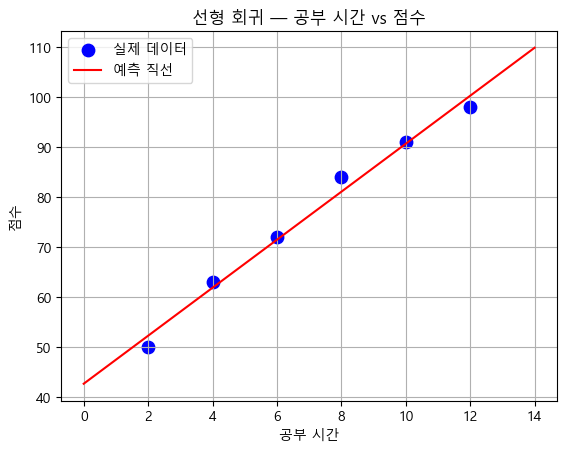

In [30]:
# 4-3. 실습 — 공부 시간으로 점수 예측 + 시각화

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([[2], [4], [6], [8], [10], [12]])
y = np.array([50, 63, 72, 84, 91, 98])

model = LinearRegression()
model.fit(X, y)

x_range = np.linspace(0, 14, 100).reshape(-1, 1)
y_pred = model.predict(x_range)

plt.scatter(X, y, color="blue", label="실제 데이터", s=80)
plt.plot(x_range, y_pred, color="red", label="예측 직선")
plt.xlabel("공부 시간")
plt.ylabel("점수")
plt.title("선형 회귀 — 공부 시간 vs 점수")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# 5-1. 분류 평가 지표

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# iris 분류 모델 재구성 (섹션 4에서 변수가 덮어씌워졌으므로)
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [32]:
# 5-2. 회귀 평가 지표

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import numpy as np

# 회귀 데이터 준비
X_reg = np.array([[2], [4], [6], [8], [10], [12]])
y_reg = np.array([50, 63, 72, 84, 91, 98])

reg_model = LinearRegression()
reg_model.fit(X_reg, y_reg)
y_reg_pred = reg_model.predict(X_reg)

print(f"MAE:  {mean_absolute_error(y_reg, y_reg_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg, y_reg_pred)):.2f}")
print(f"R²:   {r2_score(y_reg, y_reg_pred):.4f}")

MAE:  1.56
RMSE: 1.85
R²:   0.9874


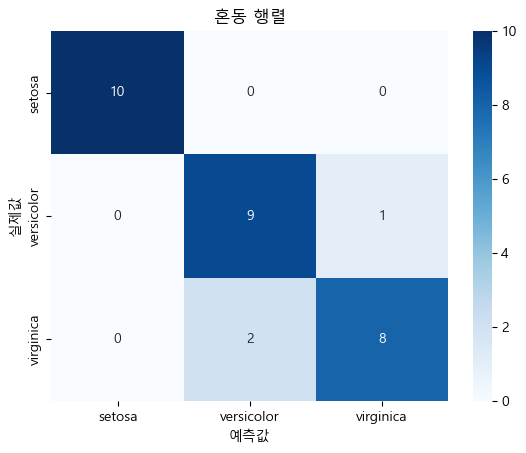

In [33]:
# 5-3. 혼동 행렬 (Confusion Matrix) 시각화

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False
from sklearn.metrics import confusion_matrix

# 5-1에서 만든 분류 결과 사용
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.xlabel("예측값")
plt.ylabel("실제값")
plt.title("혼동 행렬")
plt.show()

In [34]:
# 6-2. 표준화 / 정규화

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 5-1에서 만든 X_train, X_test 사용

# 표준화 — 평균 0, 표준편차 1로 변환
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 학습 + 변환
X_test_scaled  = scaler.transform(X_test)       # 변환만 (fit 하면 안 됨!)
print("표준화 후 평균:", X_train_scaled.mean(axis=0).round(2))
print("표준화 후 표준편차:", X_train_scaled.std(axis=0).round(2))

# 정규화 — 0~1 사이로 변환
scaler2 = MinMaxScaler()
X_train_norm = scaler2.fit_transform(X_train)
X_test_norm  = scaler2.transform(X_test)
print("\n정규화 후 최솟값:", X_train_norm.min(axis=0))
print("정규화 후 최댓값:", X_train_norm.max(axis=0))

표준화 후 평균: [-0. -0.  0.  0.]
표준화 후 표준편차: [1. 1. 1. 1.]

정규화 후 최솟값: [0. 0. 0. 0.]
정규화 후 최댓값: [1. 1. 1. 1.]


In [35]:
# 6-3. 범주형 데이터 인코딩

from sklearn.preprocessing import LabelEncoder

# LabelEncoder — 순서가 있는 데이터에 사용
le = LabelEncoder()
labels = ["개", "고양이", "새", "개", "고양이"]
print(le.fit_transform(labels))  # [0 1 2 0 1]

# OneHotEncoder — 순서가 없는 데이터에 사용 (권장)
import pandas as pd
df = pd.DataFrame({"동물": ["개", "고양이", "새"]})
encoded = pd.get_dummies(df["동물"])
print(encoded)

[0 1 2 0 1]
       개    고양이      새
0   True  False  False
1  False   True  False
2  False  False   True


In [36]:
# 7-2. Pipeline으로 한 번에 처리하기

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier())
])

pipeline.fit(X_train, y_train)
print(pipeline.score(X_test, y_test))

0.9


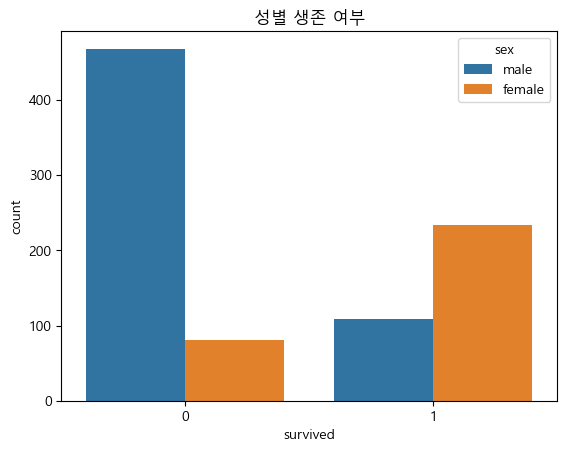

정확도: 0.7972
              precision    recall  f1-score   support

           0       0.82      0.85      0.83        85
           1       0.76      0.72      0.74        58

    accuracy                           0.80       143
   macro avg       0.79      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143



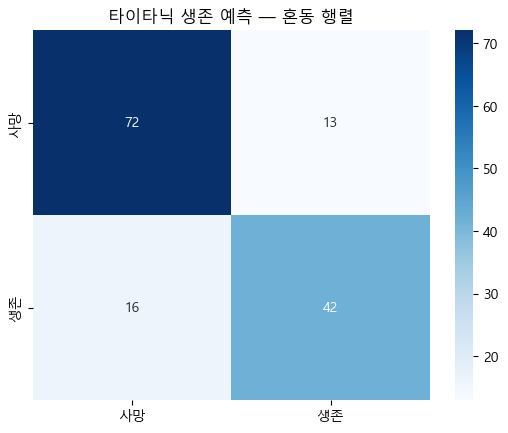

In [37]:
# 7-3. 실습 — 타이타닉 생존 예측 (처음부터 끝까지)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. 데이터 불러오기
df = sns.load_dataset("titanic")

# 2. 탐색
sns.countplot(data=df, x="survived", hue="sex")
plt.title("성별 생존 여부")
plt.show()

# 3. 전처리
df = df[["survived", "pclass", "sex", "age", "fare"]].dropna()
df["sex"] = df["sex"].map({"male": 0, "female": 1})

X = df.drop(columns=["survived"]).to_numpy()
y = df["survived"].to_numpy()

# 4. 훈련/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. 모델 학습
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. 평가
print(f"정확도: {model.score(X_test, y_test):.4f}")
print(classification_report(y_test, model.predict(X_test)))

# 7. 혼동 행렬 시각화
cm = confusion_matrix(y_test, model.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["사망", "생존"],
            yticklabels=["사망", "생존"])
plt.title("타이타닉 생존 예측 — 혼동 행렬")
plt.show()